In [2]:
import pandas as pd
import os
from pandasql import sqldf

In [50]:
traffic_path = os.path.join('data', 'Traffic\\')
read_file_excel = lambda file: pd.read_excel(os.path.join(traffic_path, file))
transaction = pd.DataFrame()
for i in os.listdir(traffic_path):
    if i.endswith('.xlsx'):
        transaction = pd.concat([transaction, read_file_excel(i)], ignore_index=True)

In [ ]:
customer_files = pd.ExcelFile(os.path.join('data', 'customers(UK).xlsx')).sheet_names
def read_sheet(sheet_name):
    return pd.read_excel(os.path.join('data', 'customers(UK).xlsx'), sheet_name=sheet_name)
customer, items, customer_transaction = [read_sheet(files) for files in customer_files]

In [61]:
total_pageview = transaction[['uniquePageviews','Posted On (DD/MM/YYYY)']]
total_pageview.rename(columns={'Posted On (DD/MM/YYYY)':'Date'},inplace=True)
total_pageview['Date'].astype('str')
total_pageview['Date2'] = total_pageview['Date'].dt.date

Exploration

In [ ]:
total_traffic = total_pageview.groupby('Date2').sum(numeric_only=True).reset_index()
total_traffic.rename(columns={'Date2':'Date','uniquePageviews':'Total_Pageview'},inplace=True)

In [71]:
pysqldf = lambda q: sqldf(q, globals())
total_pageview = pysqldf("""
    SELECT SUM(uniquePageviews) AS Total_Pageview, date(Date) AS Date 
    FROM total_pageview
    GROUP BY date(Date)
""")

Axes(0.125,0.11;0.775x0.77)


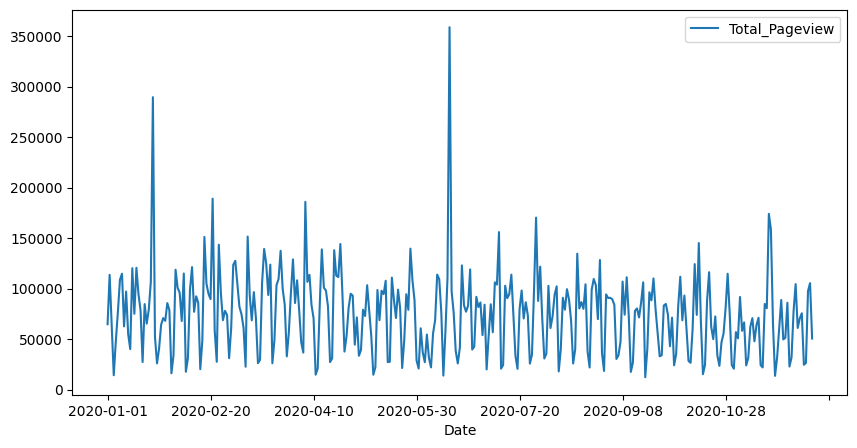

In [73]:
print(total_pageview.plot(x='Date',y='Total_Pageview',kind='line',figsize = [10,5]))

In [74]:
revenue = customer_transaction.merge(items, right_on = 'ItemID',left_on = 'ItemID',how = 'left')

In [77]:
revenue_offline = revenue[revenue['Channel'] == 'In Store']
revenue_offline = revenue_offline[['TransactionDate','SellPrice']]
revenue_online = revenue[revenue['Channel'] == 'Online']
revenue_online = revenue_online[['TransactionDate','SellPrice']]
revenue_offline = revenue_offline.groupby('TransactionDate').sum().reset_index()
revenue_online = revenue_online.groupby('TransactionDate').sum().reset_index()
revenue_online.rename(columns={'SellPrice':'Revenue'},inplace=True)
revenue_offline.rename(columns={'SellPrice':'Revenue'},inplace=True)

Axes(0.125,0.2;0.775x0.68)


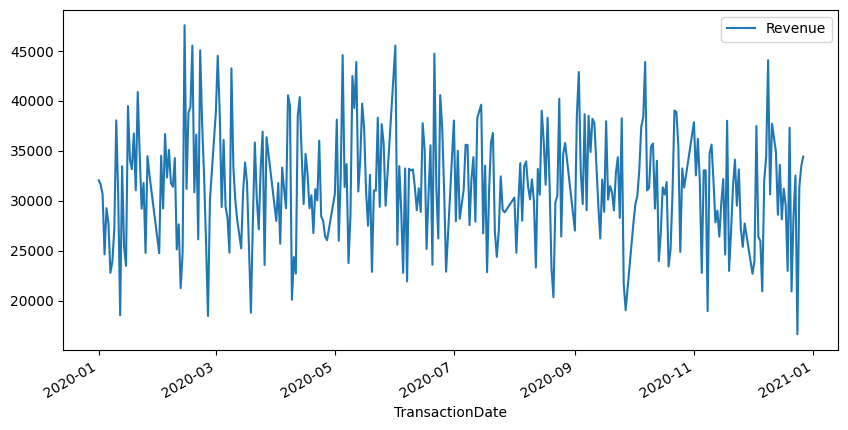

In [78]:
print(revenue_online.plot(x='TransactionDate',y='Revenue',kind='line',figsize = [10,5]))

Axes(0.125,0.2;0.775x0.68)


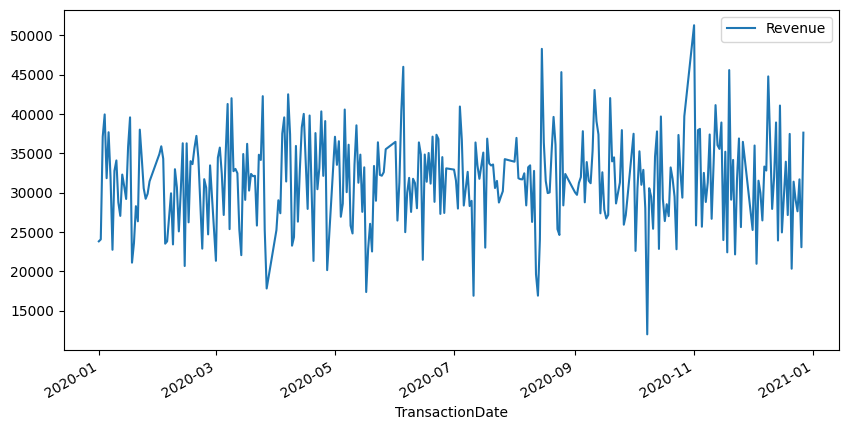

In [79]:
print(revenue_offline.plot(x='TransactionDate',y='Revenue',kind='line',figsize = [10,5]))

In [80]:
revenue_offline.rename(columns={'TransactionDate':'Date'},inplace=True)
revenue_online.rename(columns={'TransactionDate':'Date'},inplace=True)
revenue_offline.rename(columns={'Revenue':'RevenueOffline'},inplace=True)
revenue_online.rename(columns={'Revenue':'RevenueOnline'},inplace=True)

In [82]:
total_pageview['Date'] = pd.to_datetime(total_pageview['Date'])
result = total_pageview.merge(revenue_offline,on='Date',how='inner').merge(revenue_online,on='Date',how='inner')
result = result[['Total_Pageview','RevenueOffline','RevenueOnline']]
result.corr()

,Total_Pageview,RevenueOffline,RevenueOnline
Total_Pageview,1.000000,0.013554,0.095362
RevenueOffline,0.013554,1.000000,0.020564
RevenueOnline,0.095362,0.020564,1.000000


In [84]:
revenue[revenue['Product'] == '032irview0.686128260621012']

,OrderID,CustomerID,ItemID,TransactionDate,Channel,Product,Brand,SellPrice,CostPrice
21674,7193,660,1,2020-03-09,In Store,032irview0.686128260621012,"Ki)D3jDmA,RIP68X",943,359


In [98]:
transaction['Product'] = transaction['Page URL'].apply(lambda x: x.split('/')[3])
total_pageviews = transaction[['Product','pageviews']].groupby('Product').sum().reset_index()
total_revenue = revenue[['Product','SellPrice']].groupby('Product').sum().reset_index()
total_revenue.rename(columns={'SellPrice':'Revenue'},inplace=True)
product_info = total_pageviews.merge(total_revenue,on='Product',how='outer')
product_info.fillna(0,inplace=True)
product_info.sort_values(['Revenue','pageviews'],ascending=[False,False])

,Product,pageviews,Revenue
6929,hypsrview0.321288570724117,587.0,11556.0
13508,reeelease0.452821711209563,281.8,9205.0
1944,audE-info0.884915261087885,1205.6,8428.0
8310,kinv-news0.29905739542661,766.4,7980.0
17672,ymc_orson0.319251813809483,223.2,7794.0
...,...,...,...
17806,yunUvideo0.199515319377547,21.2,0.0
17067,vibJtream0.961391666643217,19.8,0.0
1972,aur`bdrab0.327125310437019,10.8,0.0
9343,maju-date0.799046146817876,2.0,0.0


In [99]:
product_info['pageviews'].describe()

count     17889.000000
mean       1592.936453
std        4412.133767
min           0.400000
25%         358.800000
50%         683.600000
75%        1499.800000
max      232177.000000
Name: pageviews, dtype: float64

In [ ]:
product_info['R'] = product_info['Revenue'].apply(lambda x: 4 if x>= 1632 else ( 3 if x < 1632 and x>= 903 
                                                            else (2 if x < 903 and x >= 177 else
                                                            1)))
product_info['P'] = product_info['pageviews'].apply(lambda x: 4 if x>= 1499 else ( 3 if x < 1499 and x>= 683.6 
                                                            else (2 if x < 683.6 and x >= 358 else
                                                            1)))

In [103]:
product_info[(product_info['R'] == 4) & (product_info['P'] == 4)]

,Product,pageviews,Revenue,R,P
0,007Jlease0.316606245376631,1917.8,1870.0,4,4
14,10-Dhibli0.14039143981496,5006.4,2302.0,4,4
18,100E-info0.758794206933415,5884.4,1904.0,4,4
30,100okbook0.549659882803086,1938.6,2110.0,4,4
87,18mO-look0.123943498316578,3100.8,2642.0,4,4
...,...,...,...,...,...
17778,youptream0.973066697229772,1681.4,2154.0,4,4
17799,yumoweler0.449723494143297,14152.6,1960.0,4,4
17832,zacTeaser0.0185417998508631,2305.2,2186.0,4,4
17842,zahq-info0.658935603966331,1522.6,1734.0,4,4


In [118]:
customer_transaction.at[0,'Transaction_ID'] = 1
for i in range(len(customer_transaction['Transaction_ID'])):
    customer_transaction.at[i,'Transaction_ID'] = i
customer_transaction['Transaction_ID'].apply(lambda x:x+1)
customer_transaction[customer_transaction['Transaction_ID'] == 1]

,OrderID,CustomerID,ItemID,TransactionDate,Channel,Transaction_ID
1,0,0,3433,2020-07-14,In Store,1.0


In [ ]:
customer.rename(columns={'ID':'CustomerID'},inplace=True)
customer_transaction.join(customer,on='CustomerID',how='left',lsuffix='CT')
customer.rename(columns={'CustomerID':'ID'},inplace=True)

In [121]:
customer_transaction.groupby('CustomerID').count()

,OrderID,ItemID,TransactionDate,Channel,Transaction_ID
CustomerID,,,,,
0,45,45,45,45,45
1,39,39,39,39,39
2,21,21,21,21,21
3,19,19,19,19,19
4,48,48,48,48,48
...,...,...,...,...,...
765,38,38,38,38,38
766,7,7,7,7,7
767,57,57,57,57,57


<Axes: xlabel='TransactionDate'>

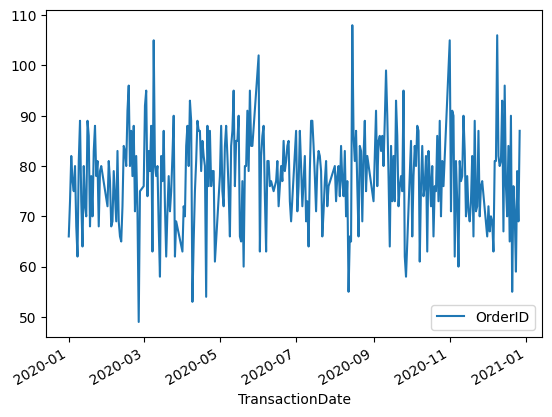

In [124]:
transaction_by_date = customer_transaction.groupby('TransactionDate')['OrderID'].count()
transaction_by_date = transaction_by_date.reset_index()
transaction_by_date.plot.line(x= 'TransactionDate',y='OrderID')

1.	What is the impact of our website traffic on revenue? 

<Axes: xlabel='TransactionDate'>

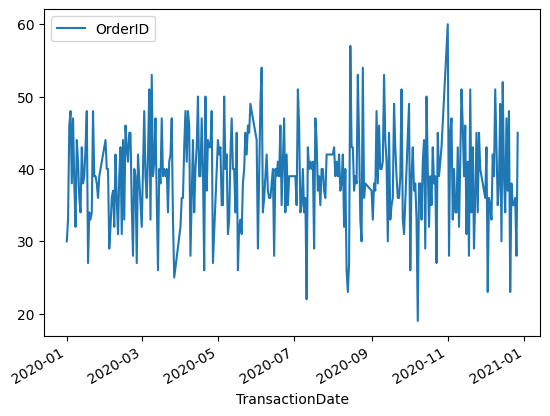

In [126]:
Question1 = customer_transaction.groupby(['TransactionDate','Channel'])['OrderID'].count().reset_index()
instore = Question1[Question1['Channel'] == 'In Store']
Online = Question1[Question1['Channel'] == 'Online']
instore.plot.line(x= 'TransactionDate',y='OrderID')

<Axes: xlabel='TransactionDate'>

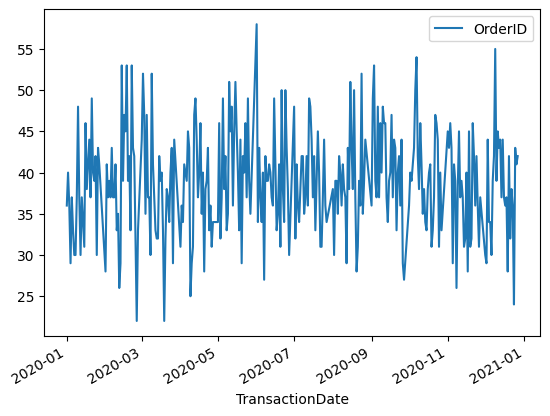

In [127]:
Online.plot.line(x= 'TransactionDate',y='OrderID')

In [128]:
import matplotlib.pyplot as plt

In [129]:
plt.style.use("seaborn-v0_8-whitegrid")

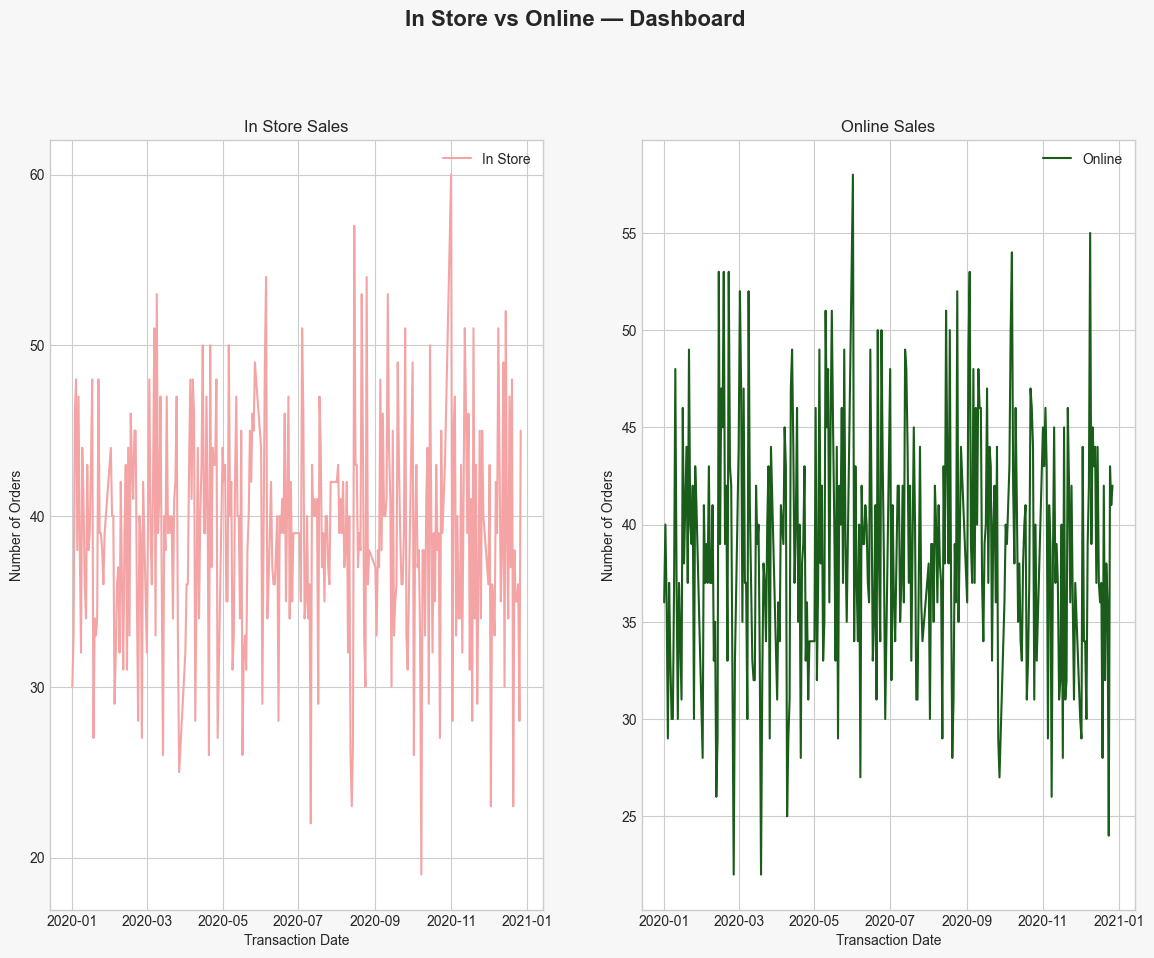

In [141]:
fig, axes = plt.subplots(
        nrows=1, ncols=2,
        figsize=(14, 10),
        facecolor="#F7F7F7"
    )
fig.suptitle("In Store vs Online — Dashboard", fontsize=16, fontweight="bold", y=1.01)
COLOR_ACHIEVED    = "#1A5C1A"   # xanh đậm
COLOR_OUTSTANDING = "#F4A4A4"   # hồng nhạt
ax1 = axes[1]
ax1.plot(Online['TransactionDate'], Online['OrderID'], color=COLOR_ACHIEVED, label='Online')
ax1.set_title("Online Sales")
ax1.set_xlabel("Transaction Date")
ax1.set_ylabel("Number of Orders")
ax1.legend()

ax2 = axes[0]
ax2.plot(instore['TransactionDate'], instore['OrderID'], color=COLOR_OUTSTANDING, label='In Store')
ax2.set_title("In Store Sales")
ax2.set_xlabel("Transaction Date")
ax2.set_ylabel("Number of Orders")
ax2.legend()


In [148]:
customer_by_date = pysqldf("""
    select TransactionDate as TransactionDate , count(distinct(CustomerID)) as Total_Customers 
from customer_transaction group by TransactionDate
""")

In [149]:
customer_by_date

,TransactionDate,Total_Customers
0,2020-01-01 00:00:00.000000,63
1,2020-01-02 00:00:00.000000,71
2,2020-01-03 00:00:00.000000,78
3,2020-01-04 00:00:00.000000,73
4,2020-01-05 00:00:00.000000,73
...,...,...
319,2020-12-23 00:00:00.000000,69
320,2020-12-24 00:00:00.000000,58
321,2020-12-25 00:00:00.000000,75
322,2020-12-26 00:00:00.000000,67
